# AdaBoost (Adaptive Boosting)
- It is a sequential ensemble machine learning algorithm that combines multiple "weak learners" to form a single, highly accurate "strong learner".
- It achieves this by iteratively training models—typically one-level decision trees called decision stumps—and dynamically increasing the weights of misclassified data points so that subsequent models focus heavily on correcting previous mistakes.

In [644]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [645]:
df = pd.DataFrame()

In [646]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [647]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

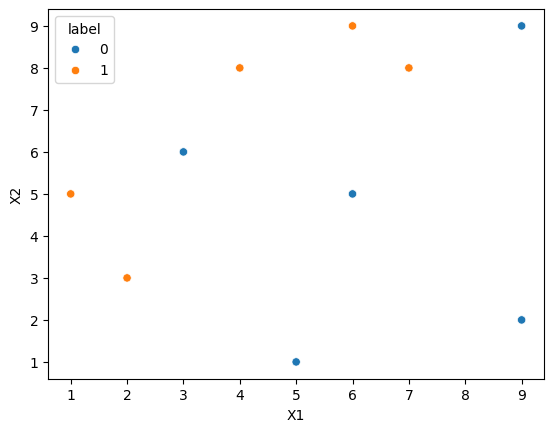

In [648]:
import seaborn as sns
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [649]:
df['weights'] = 1/df.shape[0]

In [650]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [651]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(max_depth=1) # decision Stump

In [652]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [653]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

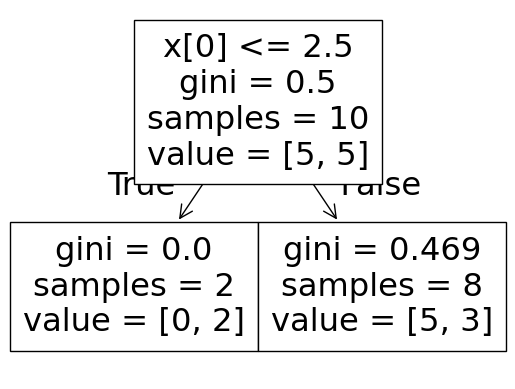

In [654]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

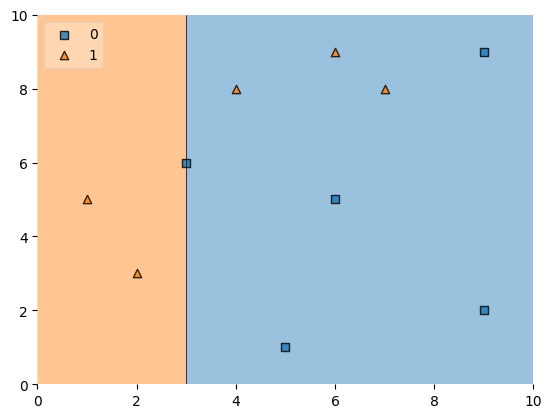

In [655]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [656]:
df['y_pred'] = dt1.predict(X)

In [657]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [658]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error))

### Calculate model weight

In [659]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

### Update weights or Upsampling the incorrectly classified points

In [660]:
def update_row_weights(row, alpha=0.423):
  if row['label'] == row['y_pred']:  # if points are correctly classified, decreased the weights
    return row['weights']*np.exp(-alpha)
  else:  # if points are incorrectly classified, then Increased the weigths
    return row['weights']*np.exp(alpha)

In [661]:
df['updated_weights'] = df.apply(update_row_weights, axis=1)

In [662]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [663]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [664]:
df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()

In [665]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [666]:
df['normalized_weights'].sum()

np.float64(1.0)

In [667]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [668]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [669]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


### Take random values and find the range and return the indices for those random values

In [670]:
def create_new_dataset(df):
  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper']>a and a>row['cumsum_lower']:
        indices.append(index)
  return indices

In [671]:
index_values = create_new_dataset(df)
index_values

[1, 3, 2, 0, 8, 7, 5, 3, 3, 5]

In [672]:
second_df = df.iloc[index_values,[0,1,2,3]]
second_df

,X1,X2,label,weights
1,2,3,1,0.1
3,4,8,1,0.1
2,3,6,0,0.1
0,1,5,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
5,6,9,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1


In [673]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [674]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [675]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.625, 0.5, '  False')]

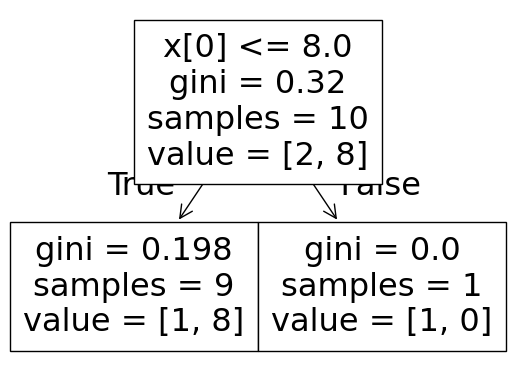

In [676]:
plot_tree(dt2)

<Axes: >

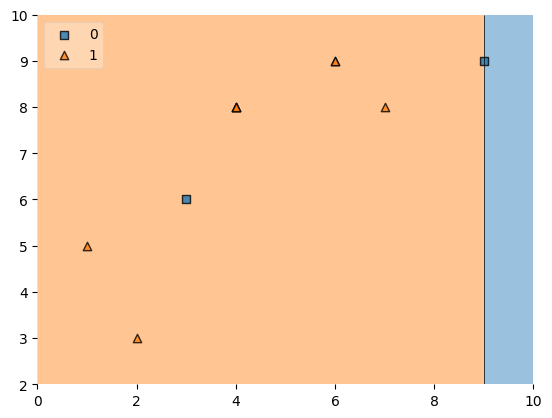

In [677]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [678]:
second_df['y_pred'] = dt2.predict(X)
second_df

,X1,X2,label,weights,y_pred
1,2,3,1,0.1,1
3,4,8,1,0.1,1
2,3,6,0,0.1,1
0,1,5,1,0.1,1
8,9,9,0,0.1,0
7,7,8,1,0.1,1
5,6,9,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
5,6,9,1,0.1,1


In [696]:
alpha2 = calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886681098)

In [697]:
def update_row_weights(row, alpha=1.098):
  if row['label'] == row['y_pred']:  # if points are correctly classified, decreased the weights
    return row['weights']*np.exp(-alpha)
  else:  # if points are incorrectly classified, then Increased the weigths
    return row['weights']*np.exp(alpha)

In [698]:
second_df['updated_weights'] = second_df.apply(update_row_weights, axis=1)

In [699]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
1,2,3,1,0.1,1,0.033354,0.07693,0.07693,0.00000
3,4,8,1,0.1,1,0.033354,0.07693,0.15386,0.07693
2,3,6,0,0.1,1,0.299816,0.30763,0.46149,0.15386
0,1,5,1,0.1,1,0.033354,0.07693,0.53842,0.46149
8,9,9,0,0.1,0,0.033354,0.07693,0.61535,0.53842
7,7,8,1,0.1,1,0.033354,0.07693,0.69228,0.61535
5,6,9,1,0.1,1,0.033354,0.07693,0.76921,0.69228
3,4,8,1,0.1,1,0.033354,0.07693,0.84614,0.76921
3,4,8,1,0.1,1,0.033354,0.07693,0.92307,0.84614
5,6,9,1,0.1,1,0.033354,0.07693,1.00000,0.92307


In [700]:
second_df['updated_weights'].sum()

np.float64(0.6000001124692275)

In [701]:
second_df['normalized_weights'] = second_df['updated_weights'] / second_df['updated_weights'].sum()
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
1,2,3,1,0.1,1,0.033354,0.055590,0.07693,0.00000
3,4,8,1,0.1,1,0.033354,0.055590,0.15386,0.07693
2,3,6,0,0.1,1,0.299816,0.499694,0.46149,0.15386
0,1,5,1,0.1,1,0.033354,0.055590,0.53842,0.46149
8,9,9,0,0.1,0,0.033354,0.055590,0.61535,0.53842
7,7,8,1,0.1,1,0.033354,0.055590,0.69228,0.61535
5,6,9,1,0.1,1,0.033354,0.055590,0.76921,0.69228
3,4,8,1,0.1,1,0.033354,0.055590,0.84614,0.76921
3,4,8,1,0.1,1,0.033354,0.055590,0.92307,0.84614
5,6,9,1,0.1,1,0.033354,0.055590,1.00000,0.92307


In [702]:
second_df['normalized_weights'].sum()

np.float64(1.0)

In [703]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])

In [704]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

In [705]:
second_df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
1,2,3,1,0.1,1,0.033354,0.000000,0.055590
3,4,8,1,0.1,1,0.033354,0.055590,0.111179
2,3,6,0,0.1,1,0.299816,0.111179,0.610873
0,1,5,1,0.1,1,0.033354,0.610873,0.666463
8,9,9,0,0.1,0,0.033354,0.666463,0.722052
7,7,8,1,0.1,1,0.033354,0.722052,0.777642
5,6,9,1,0.1,1,0.033354,0.777642,0.833231
3,4,8,1,0.1,1,0.033354,0.833231,0.888821
3,4,8,1,0.1,1,0.033354,0.888821,0.944410
5,6,9,1,0.1,1,0.033354,0.944410,1.000000


In [706]:
index_values = create_new_dataset(second_df)
index_values

[7, 5, 2, 8, 2, 8, 3, 0, 2, 2]

In [707]:
third_df = second_df.iloc[index_values,[0,1,2,3]]
third_df

,X1,X2,label,weights
3,4,8,1,0.1
7,7,8,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1


In [708]:
dt3 = DecisionTreeClassifier(max_depth=1)
X = third_df.iloc[:,0:2].values
y = third_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.625, 0.5, '  False')]

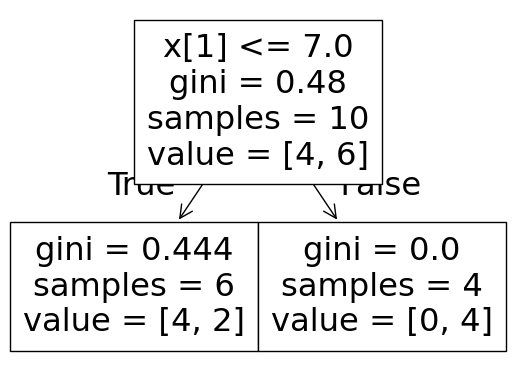

In [709]:
plot_tree(dt3)

<Axes: >

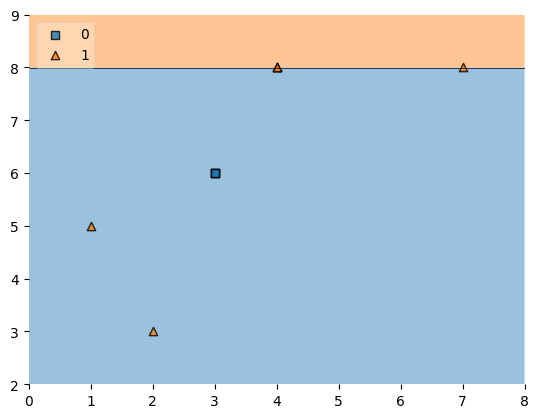

In [710]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [711]:
third_df['y_pred'] = dt3.predict(X)
third_df

,X1,X2,label,weights,y_pred
3,4,8,1,0.1,1
7,7,8,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,1
0,1,5,1,0.1,0
1,2,3,1,0.1,0
2,3,6,0,0.1,0
2,3,6,0,0.1,0


In [712]:
alpha3 = calculate_model_weight(0.2)
alpha3

np.float64(0.6931471805599453)

In [713]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 0.6931471805599453


# Prediction

In [714]:
# Prediction 1
query = np.array([1,5]).reshape(1,2)

In [715]:
dt1.predict(query)

array([1])

In [716]:
dt2.predict(query)

array([1])

In [717]:
dt3.predict(query)

array([0])

In [722]:
alpha1*1 + alpha2*1 + alpha3*(-1)

np.float64(0.8291140383017664)

In [723]:
np.sign(0.829)

np.float64(1.0)

In [724]:
# Prediction 2
query = np.array([9,9]).reshape(1,2)
print(dt1.predict(query))
print(dt2.predict(query))
print(dt3.predict(query))

[0]
[0]
[1]


In [725]:
alpha1*(-1) + alpha2*(-1) + alpha3*1

np.float64(-0.8291140383017664)

In [726]:
np.sign(-0.829)

np.float64(-1.0)